In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

TASK 1

In [7]:
city=pd.read_csv('city_day.csv')
crop=pd.read_csv('crop_production.csv')

In [8]:
#All about the city dataset
print("Shape:", city.shape)          # (29531, 16)
print(city.dtypes)
print(city.isnull().sum())
print(city.describe())
print(city.head())

Shape: (29531, 16)
City           object
Date           object
PM2.5         float64
PM10          float64
NO            float64
NO2           float64
NOx           float64
NH3           float64
CO            float64
SO2           float64
O3            float64
Benzene       float64
Toluene       float64
Xylene        float64
AQI           float64
AQI_Bucket     object
dtype: object
City              0
Date              0
PM2.5          4598
PM10          11140
NO             3582
NO2            3585
NOx            4185
NH3           10328
CO             2059
SO2            3854
O3             4022
Benzene        5623
Toluene        8041
Xylene        18109
AQI            4681
AQI_Bucket     4681
dtype: int64
              PM2.5          PM10            NO           NO2           NOx  \
count  24933.000000  18391.000000  25949.000000  25946.000000  25346.000000   
mean      67.450578    118.127103     17.574730     28.560659     32.309123   
std       64.661449     90.605110     22.7858

In [10]:
city.head()

,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
0,Ahmedabad,2015-01-01,NaN,NaN,0.92,18.22,17.15,NaN,0.92,27.64,133.36,0.00,0.02,0.00,NaN,NaN
1,Ahmedabad,2015-01-02,NaN,NaN,0.97,15.69,16.46,NaN,0.97,24.55,34.06,3.68,5.50,3.77,NaN,NaN
2,Ahmedabad,2015-01-03,NaN,NaN,17.40,19.30,29.70,NaN,17.40,29.07,30.70,6.80,16.40,2.25,NaN,NaN
3,Ahmedabad,2015-01-04,NaN,NaN,1.70,18.48,17.97,NaN,1.70,18.59,36.08,4.43,10.14,1.00,NaN,NaN
4,Ahmedabad,2015-01-05,NaN,NaN,22.10,21.42,37.76,NaN,22.10,39.33,39.31,7.01,18.89,2.78,NaN,NaN


In [9]:
#All about the crop dataset
print("Shape:", crop.shape)          # (29531, 16)
print(crop.dtypes)
print(crop.isnull().sum())
print(crop.describe())
print(crop.head())

Shape: (246091, 7)
State_Name        object
District_Name     object
Crop_Year          int64
Season            object
Crop              object
Area             float64
Production       float64
dtype: object
State_Name          0
District_Name       0
Crop_Year           0
Season              0
Crop                0
Area                0
Production       3730
dtype: int64
           Crop_Year          Area    Production
count  246091.000000  2.460910e+05  2.423610e+05
mean     2005.643018  1.200282e+04  5.825034e+05
std         4.952164  5.052340e+04  1.706581e+07
min      1997.000000  4.000000e-02  0.000000e+00
25%      2002.000000  8.000000e+01  8.800000e+01
50%      2006.000000  5.820000e+02  7.290000e+02
75%      2010.000000  4.392000e+03  7.023000e+03
max      2015.000000  8.580100e+06  1.250800e+09
                    State_Name District_Name  Crop_Year       Season  \
0  Andaman and Nicobar Islands      NICOBARS       2000  Kharif        
1  Andaman and Nicobar Islands      NICO

In [11]:
crop.head()

,State_Name,District_Name,Crop_Year,Season,Crop,Area,Production
0,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Arecanut,1254.0,2000.0
1,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Other Kharif pulses,2.0,1.0
2,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Rice,102.0,321.0
3,Andaman and Nicobar Islands,NICOBARS,2000,Whole Year,Banana,176.0,641.0
4,Andaman and Nicobar Islands,NICOBARS,2000,Whole Year,Cashewnut,720.0,165.0


"Xylene is missing in 61% of rows in city_day — it cannot be reliably imputed and may need to be dropped. AQI reaches 2049 which far exceeds the standard scale maximum of 500, suggesting data entry errors or sensor faults."



TASK 2


In [ ]:
# Before
print("Before cleaning:")
print(city.isnull().sum())

# Drop Xylene (too many nulls)
city.drop(columns=['Xylene'], inplace=True)

# Impute pollutant columns with median
for col in ['PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3', 'Benzene', 'Toluene']:
    city[col].fillna(city[col].median(), inplace=True)

# Drop rows where AQI is null (it's the target variable)
city.dropna(subset=['AQI', 'AQI_Bucket'], inplace=True)

# Crop: impute Production with median
crop['Production'].fillna(crop['Production'].median(), inplace=True)

# After — prove it worked
print("After cleaning:")
print(city.isnull().sum())
print(crop.isnull().sum())

Before cleaning:
City          0
Date          0
PM2.5         0
PM10          0
NO            0
NO2           0
NOx           0
NH3           0
CO            0
SO2           0
O3            0
Benzene       0
Toluene       0
AQI           0
AQI_Bucket    0
dtype: int64


KeyError: "['Xylene'] not found in axis"

TASK 3

In [15]:
print("Unique states in crop dataset:")
print(sorted(crop['State_Name'].unique()))
# You'll see: 'Jammu and Kashmir ' (trailing space), 'Telangana ' (trailing space)

Unique states in crop dataset:
['Andaman and Nicobar Islands', 'Andhra Pradesh', 'Arunachal Pradesh', 'Assam', 'Bihar', 'Chandigarh', 'Chhattisgarh', 'Dadra and Nagar Haveli', 'Goa', 'Gujarat', 'Haryana', 'Himachal Pradesh', 'Jammu and Kashmir ', 'Jharkhand', 'Karnataka', 'Kerala', 'Madhya Pradesh', 'Maharashtra', 'Manipur', 'Meghalaya', 'Mizoram', 'Nagaland', 'Odisha', 'Puducherry', 'Punjab', 'Rajasthan', 'Sikkim', 'Tamil Nadu', 'Telangana ', 'Tripura', 'Uttar Pradesh', 'Uttarakhand', 'West Bengal']


In [16]:
#FIXING
# Record count before
print("Crop rows before:", len(crop))

# Fix trailing spaces / standardise
crop['State_Name'] = crop['State_Name'].str.strip()

# Fix known name variants (old names to current names)
crop['State_Name'] = crop['State_Name'].replace({
    'Jammu and Kashmir': 'Jammu & Kashmir',  # if needed for merge
})

# Removing duplicates
city_before = len(city)
crop_before = len(crop)

city.drop_duplicates(inplace=True)
crop.drop_duplicates(inplace=True)

print(f"City: {city_before} → {len(city)} rows")
print(f"Crop: {crop_before} → {len(crop)} rows")

Crop rows before: 246091
City: 24850 → 24850 rows
Crop: 246091 → 246091 rows


Task 4 — AQI Distribution Visualisation

where do most cities cluster, and are extremes distorting the average?

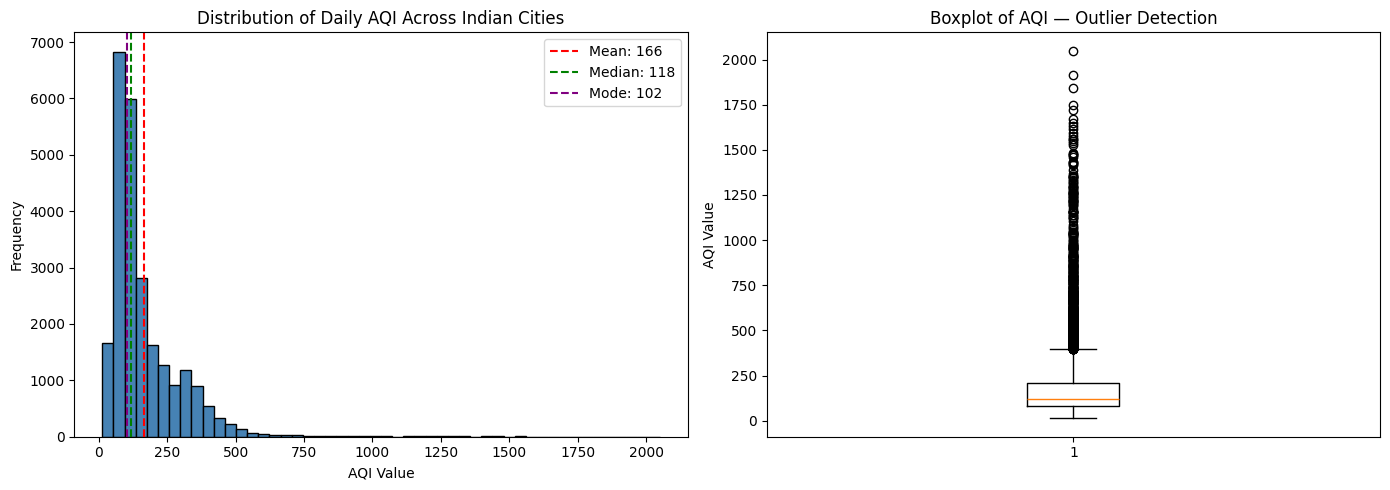

In [18]:
aqi = city["AQI"].dropna()
mean_val = aqi.mean()
median_val = aqi.median()
mode_val = aqi.mode().iloc[0]   # first mode if there are multiple

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(aqi, bins=50, color='steelblue', edgecolor='black')
axes[0].axvline(mean_val, color='red', linestyle='--', label=f"Mean: {mean_val:.0f}")
axes[0].axvline(median_val, color='green', linestyle='--', label=f"Median: {median_val:.0f}")
axes[0].axvline(mode_val, color='purple', linestyle='--', label=f"Mode: {mode_val:.0f}")
axes[0].set_xlabel('AQI Value')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Daily AQI Across Indian Cities')
axes[0].legend()

axes[1].boxplot(aqi, vert=True)
axes[1].set_ylabel('AQI Value')
axes[1].set_title('Boxplot of AQI — Outlier Detection')

plt.tight_layout()
plt.show()

observations  .
->The histogram is right-skewed — most cities have AQI between 50–250, meaning moderate pollution is the norm, not the exception.
->The mean AQI (~166) is significantly higher than the median (~118), showing that a small number of extreme readings pull the average up. The median is a fairer number to report publicly.\.